In [1]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
%matplotlib inline
import matplotlib
matplotlib.rcParams["figure.figsize"] = (20,10) 

In [2]:
df = pd.read_csv("Bengaluru_House_Data.csv")
df.head()                                                                                       

,area_type,availability,location,size,society,total_sqft,bath,balcony,price
0,Super built-up Area,19-Dec,Electronic City Phase II,2 BHK,Coomee,1056,2.0,1.0,39.07
1,Plot Area,Ready To Move,Chikka Tirupathi,4 Bedroom,Theanmp,2600,5.0,3.0,120.00
2,Built-up Area,Ready To Move,Uttarahalli,3 BHK,NaN,1440,2.0,3.0,62.00
3,Super built-up Area,Ready To Move,Lingadheeranahalli,3 BHK,Soiewre,1521,3.0,1.0,95.00
4,Super built-up Area,Ready To Move,Kothanur,2 BHK,NaN,1200,2.0,1.0,51.00


In [67]:
df.shape

(13320, 9)

In [68]:
df['area_type'].value_counts() 

area_type
Super built-up  Area    8790
Built-up  Area          2418
Plot  Area              2025
Carpet  Area              87
Name: count, dtype: int64

In [69]:
df1=df.drop(['area_type','availability','society','balcony'],axis='columns')
df1.shape 

(13320, 5)

In [70]:
# Data cleaning process starts here 
df1.isnull().sum() #To check how many responces are null in every column

location       1
size          16
total_sqft     0
bath          73
price          0
dtype: int64

In [71]:
# if the total number of entries (rows) are very much greater than the null ones we can drop them 
# 13320>>609 so we dropped the null ones 
# if the total entries we had was much lesser we would have filled the empty ones with median of that column
df2=df1.dropna()
df2.isnull().sum()
df2.shape 

(13246, 5)

In [72]:
df2['size'].unique() 

array(['2 BHK', '4 Bedroom', '3 BHK', '4 BHK', '6 Bedroom', '3 Bedroom',
       '1 BHK', '1 RK', '1 Bedroom', '8 Bedroom', '2 Bedroom',
       '7 Bedroom', '5 BHK', '7 BHK', '6 BHK', '5 Bedroom', '11 BHK',
       '9 BHK', '9 Bedroom', '27 BHK', '10 Bedroom', '11 Bedroom',
       '10 BHK', '19 BHK', '16 BHK', '43 Bedroom', '14 BHK', '8 BHK',
       '12 Bedroom', '13 BHK', '18 Bedroom'], dtype=object)

In [9]:
def object_to_int(x) :
    lis=x.split(" ") 
    return int(lis[0])

df2['bhk']=df2['size'].apply(object_to_int)  
df2.head()          

C:\Users\os\AppData\Local\Temp\ipykernel_4900\3108300051.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df2['bhk']=df2['size'].apply(object_to_int)


,location,size,total_sqft,bath,price,bhk
0,Electronic City Phase II,2 BHK,1056,2.0,39.07,2
1,Chikka Tirupathi,4 Bedroom,2600,5.0,120.00,4
2,Uttarahalli,3 BHK,1440,2.0,62.00,3
3,Lingadheeranahalli,3 BHK,1521,3.0,95.00,3
4,Kothanur,2 BHK,1200,2.0,51.00,2


In [10]:
df2[df2['bhk']>20] 

# Here observe the 2nd row carefully a 43 bhk flat or house cannot fit in 2400 sqft area so it is an error now we will correct these errors

,location,size,total_sqft,bath,price,bhk
1718,2Electronic City Phase II,27 BHK,8000,27.0,230.0,27
4684,Munnekollal,43 Bedroom,2400,40.0,660.0,43


In [11]:
# Now we will correct these errors
df2['total_sqft'].unique() 
# In total_sqft column we have range of values as well and also we need to convert it into a float value and replace range by their avg.

array(['1056', '2600', '1440', ..., '1133 - 1384', '774', '4689'],
      shape=(2067,), dtype=object)

In [12]:
def to_float(x) :
    try :
         float(x) 
    except :
        return False
    return True
    
df2[~df2['total_sqft'].apply(to_float)].head(10) 
    

,location,size,total_sqft,bath,price,bhk
30,Yelahanka,4 BHK,2100 - 2850,4.0,186.000,4
122,Hebbal,4 BHK,3067 - 8156,4.0,477.000,4
137,8th Phase JP Nagar,2 BHK,1042 - 1105,2.0,54.005,2
165,Sarjapur,2 BHK,1145 - 1340,2.0,43.490,2
188,KR Puram,2 BHK,1015 - 1540,2.0,56.800,2
410,Kengeri,1 BHK,34.46Sq. Meter,1.0,18.500,1
549,Hennur Road,2 BHK,1195 - 1440,2.0,63.770,2
648,Arekere,9 Bedroom,4125Perch,9.0,265.000,9
661,Yelahanka,2 BHK,1120 - 1145,2.0,48.130,2
672,Bettahalsoor,4 Bedroom,3090 - 5002,4.0,445.000,4


In [13]:
def range_to_avg(x) :
    list=x.split('-')
    if len(list)==2 :
        return (float(list[0]) + float(list[1]))/2
    try :
        return float(x)  
    except :
        return None 

In [14]:
df3=df2.copy()                                                                                        
df3['total_sqft']=df3['total_sqft'].apply(range_to_avg)                                  

In [15]:
df3=df3.dropna() 
df3.head()                                                                                                                   

,location,size,total_sqft,bath,price,bhk
0,Electronic City Phase II,2 BHK,1056.0,2.0,39.07,2
1,Chikka Tirupathi,4 Bedroom,2600.0,5.0,120.00,4
2,Uttarahalli,3 BHK,1440.0,2.0,62.00,3
3,Lingadheeranahalli,3 BHK,1521.0,3.0,95.00,3
4,Kothanur,2 BHK,1200.0,2.0,51.00,2


In [16]:
df4=df3.copy()
df4['price_per_sqft']= df4['price']*100000/df4['total_sqft']
df4.head() 

,location,size,total_sqft,bath,price,bhk,price_per_sqft
0,Electronic City Phase II,2 BHK,1056.0,2.0,39.07,2,3699.810606
1,Chikka Tirupathi,4 Bedroom,2600.0,5.0,120.00,4,4615.384615
2,Uttarahalli,3 BHK,1440.0,2.0,62.00,3,4305.555556
3,Lingadheeranahalli,3 BHK,1521.0,3.0,95.00,3,6245.890861
4,Kothanur,2 BHK,1200.0,2.0,51.00,2,4250.000000


In [17]:
df4['location']=df4['location'].apply(lambda x : x.strip()) ## To remove the spaces at the end of the location

In [18]:
location_stats=df4['location'].value_counts() 
location_stats

location
Whitefield                   533
Sarjapur  Road               392
Electronic City              304
Kanakpura Road               264
Thanisandra                  235
                            ... 
Rajanna Layout                 1
Subramanyanagar                1
Lakshmipura Vidyaanyapura      1
Malur Hosur Road               1
Abshot Layout                  1
Name: count, Length: 1287, dtype: int64

In [19]:
len(location_stats[location_stats<=10])

1047

In [20]:
location_dp_less_than_10=location_stats[location_stats<=10]
location_dp_less_than_10.sum() 

np.int64(2872)

In [21]:
len(df4['location'].unique())

1287

In [22]:
df4['location']=df4['location'].apply( lambda x: 'other' if x in location_dp_less_than_10 else x)
df4[df4['location']=='other']

,location,size,total_sqft,bath,price,bhk,price_per_sqft
9,other,6 Bedroom,1020.0,6.0,370.00,6,36274.509804
18,other,3 BHK,2770.0,4.0,290.00,3,10469.314079
19,other,2 BHK,1100.0,2.0,48.00,2,4363.636364
25,other,3 BHK,1250.0,3.0,56.00,3,4480.000000
42,other,1 BHK,600.0,1.0,38.00,1,6333.333333
...,...,...,...,...,...,...,...
13291,other,1 Bedroom,812.0,1.0,26.00,1,3201.970443
13292,other,3 BHK,1440.0,2.0,63.93,3,4439.583333
13302,other,2 BHK,1075.0,2.0,48.00,2,4465.116279
13306,other,4 Bedroom,1200.0,5.0,325.00,4,27083.333333


In [23]:
df4

,location,size,total_sqft,bath,price,bhk,price_per_sqft
0,Electronic City Phase II,2 BHK,1056.0,2.0,39.07,2,3699.810606
1,Chikka Tirupathi,4 Bedroom,2600.0,5.0,120.00,4,4615.384615
2,Uttarahalli,3 BHK,1440.0,2.0,62.00,3,4305.555556
3,Lingadheeranahalli,3 BHK,1521.0,3.0,95.00,3,6245.890861
4,Kothanur,2 BHK,1200.0,2.0,51.00,2,4250.000000
...,...,...,...,...,...,...,...
13315,Whitefield,5 Bedroom,3453.0,4.0,231.00,5,6689.834926
13316,other,4 BHK,3600.0,5.0,400.00,4,11111.111111
13317,Raja Rajeshwari Nagar,2 BHK,1141.0,2.0,60.00,2,5258.545136
13318,Padmanabhanagar,4 BHK,4689.0,4.0,488.00,4,10407.336319


In [24]:
len(df4['location'].unique())  

241

In [25]:
df4


,location,size,total_sqft,bath,price,bhk,price_per_sqft
0,Electronic City Phase II,2 BHK,1056.0,2.0,39.07,2,3699.810606
1,Chikka Tirupathi,4 Bedroom,2600.0,5.0,120.00,4,4615.384615
2,Uttarahalli,3 BHK,1440.0,2.0,62.00,3,4305.555556
3,Lingadheeranahalli,3 BHK,1521.0,3.0,95.00,3,6245.890861
4,Kothanur,2 BHK,1200.0,2.0,51.00,2,4250.000000
...,...,...,...,...,...,...,...
13315,Whitefield,5 Bedroom,3453.0,4.0,231.00,5,6689.834926
13316,other,4 BHK,3600.0,5.0,400.00,4,11111.111111
13317,Raja Rajeshwari Nagar,2 BHK,1141.0,2.0,60.00,2,5258.545136
13318,Padmanabhanagar,4 BHK,4689.0,4.0,488.00,4,10407.336319


In [26]:
# Assumming we went to our real estate expert and ask him what is the ideal total_sqft per bhk. he told us it is about 300 sqft per bhk.(min.)
df4['total_sqft_per_bhk']=df4['total_sqft']/df4['bhk']
df4 

,location,size,total_sqft,bath,price,bhk,price_per_sqft,total_sqft_per_bhk
0,Electronic City Phase II,2 BHK,1056.0,2.0,39.07,2,3699.810606,528.00
1,Chikka Tirupathi,4 Bedroom,2600.0,5.0,120.00,4,4615.384615,650.00
2,Uttarahalli,3 BHK,1440.0,2.0,62.00,3,4305.555556,480.00
3,Lingadheeranahalli,3 BHK,1521.0,3.0,95.00,3,6245.890861,507.00
4,Kothanur,2 BHK,1200.0,2.0,51.00,2,4250.000000,600.00
...,...,...,...,...,...,...,...,...
13315,Whitefield,5 Bedroom,3453.0,4.0,231.00,5,6689.834926,690.60
13316,other,4 BHK,3600.0,5.0,400.00,4,11111.111111,900.00
13317,Raja Rajeshwari Nagar,2 BHK,1141.0,2.0,60.00,2,5258.545136,570.50
13318,Padmanabhanagar,4 BHK,4689.0,4.0,488.00,4,10407.336319,1172.25


In [27]:
df5=df4[~(df4['total_sqft_per_bhk']<=300)]
df5  #Now we have a data set where total_sqft_per bhk is greater than 300

,location,size,total_sqft,bath,price,bhk,price_per_sqft,total_sqft_per_bhk
0,Electronic City Phase II,2 BHK,1056.0,2.0,39.07,2,3699.810606,528.00
1,Chikka Tirupathi,4 Bedroom,2600.0,5.0,120.00,4,4615.384615,650.00
2,Uttarahalli,3 BHK,1440.0,2.0,62.00,3,4305.555556,480.00
3,Lingadheeranahalli,3 BHK,1521.0,3.0,95.00,3,6245.890861,507.00
4,Kothanur,2 BHK,1200.0,2.0,51.00,2,4250.000000,600.00
...,...,...,...,...,...,...,...,...
13315,Whitefield,5 Bedroom,3453.0,4.0,231.00,5,6689.834926,690.60
13316,other,4 BHK,3600.0,5.0,400.00,4,11111.111111,900.00
13317,Raja Rajeshwari Nagar,2 BHK,1141.0,2.0,60.00,2,5258.545136,570.50
13318,Padmanabhanagar,4 BHK,4689.0,4.0,488.00,4,10407.336319,1172.25


In [28]:
df5.shape

(12274, 8)

In [29]:
df5['price_per_sqft'].describe() 

count     12274.000000
mean       6211.880230
std        4053.214807
min         267.829813
25%        4200.000000
50%        5263.157895
75%        6825.474875
max      176470.588235
Name: price_per_sqft, dtype: float64

In [30]:
df5.groupby('location')['price_per_sqft'].describe()

,count,mean,std,min,25%,50%,75%,max
location,,,,,,,,
1st Block Jayanagar,10.0,12359.253758,3931.939592,6000.000000,11100.460123,12258.569501,15018.022329,18750.000000
1st Phase JP Nagar,21.0,9192.412831,3546.668595,5274.725275,7173.601148,8425.613866,9633.027523,21052.631579
2nd Phase Judicial Layout,11.0,4048.701183,674.730658,3500.000000,3500.000000,3500.000000,4739.316239,5000.000000
2nd Stage Nagarbhavi,7.0,12894.973545,5023.499500,5666.666667,10333.333333,14814.814815,15183.333333,18750.000000
5th Block Hbr Layout,6.0,4878.584533,834.302476,3611.111111,4433.589628,4951.297881,5448.644853,5882.352941
...,...,...,...,...,...,...,...,...
Yelahanka,204.0,5208.350050,1749.999579,371.428571,4297.152632,5040.371473,5874.257960,19875.776398
Yelahanka New Town,37.0,5658.695722,3735.404644,1875.000000,3750.000000,5003.126954,5376.344086,22475.000000
Yelenahalli,13.0,4012.550871,533.259531,3125.000000,3800.000000,3835.625000,4121.212121,5176.876618


In [31]:
# Each location will have its own mean and std for price_per_sqft 
def remove_pps_outlier(df) :
    df_out = pd.DataFrame()
    for key,mini_df in df.groupby('location'):
        mean= np.mean(mini_df['price_per_sqft'])
        std= np.std(mini_df['price_per_sqft'])
        reduced_df= mini_df[(mini_df['price_per_sqft']>(mean-std) ) & (mini_df['price_per_sqft']<(mean+std))]
        df_out= pd.concat([df_out,reduced_df],ignore_index=True) 
    return df_out

In [32]:
df6=remove_pps_outlier(df5)
df6.shape

(10018, 8)

In [33]:
df6

,location,size,total_sqft,bath,price,bhk,price_per_sqft,total_sqft_per_bhk
0,1st Block Jayanagar,4 BHK,2850.0,4.0,428.00,4,15017.543860,712.500000
1,1st Block Jayanagar,3 BHK,1630.0,3.0,194.00,3,11901.840491,543.333333
2,1st Block Jayanagar,3 BHK,1875.0,2.0,235.00,3,12533.333333,625.000000
3,1st Block Jayanagar,3 BHK,1200.0,2.0,130.00,3,10833.333333,400.000000
4,1st Block Jayanagar,2 BHK,1235.0,2.0,148.00,2,11983.805668,617.500000
...,...,...,...,...,...,...,...,...
10013,other,2 BHK,1353.0,2.0,110.00,2,8130.081301,676.500000
10014,other,1 Bedroom,812.0,1.0,26.00,1,3201.970443,812.000000
10015,other,3 BHK,1440.0,2.0,63.93,3,4439.583333,480.000000
10016,other,2 BHK,1075.0,2.0,48.00,2,4465.116279,537.500000


In [34]:
def plot_scatter_chart(df, location) :
    bhk2 = df[(df['location']==location) & (df['bhk']==2)]
    bhk3 = df[(df['location']==location) & (df['bhk']==3)]
    matplotlib.rcParams['figure.figsize']=(10,7)
    plt.scatter(bhk2['total_sqft'], bhk2['price'],color='blue',label='2 bhk',s =50)
    plt.scatter(bhk3['total_sqft'],bhk3['price'],marker='+',color='green',label ='3 bhk',s=50)
    plt.xlabel('Total Square Feet Area')
    plt.ylabel('Price')
    plt.title(location)
    plt.legend() 

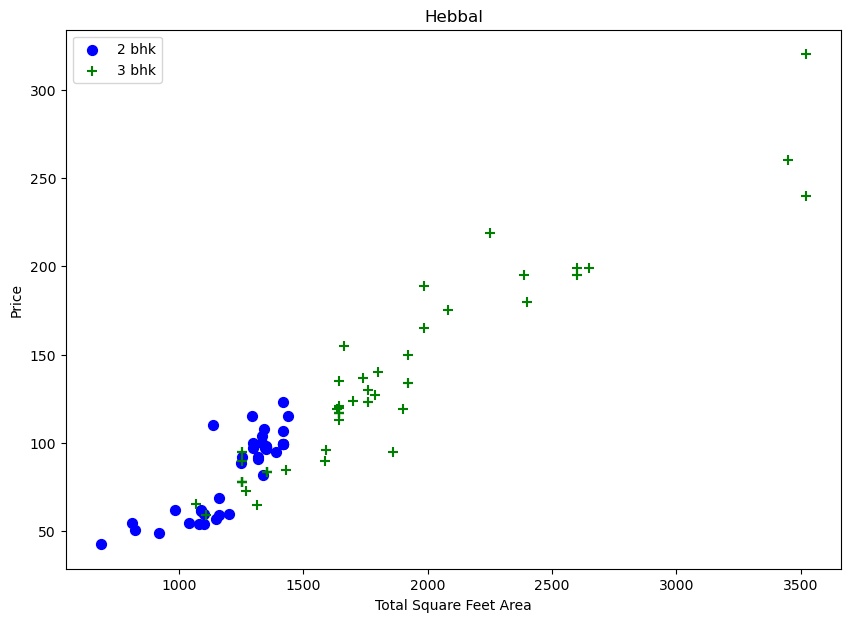

In [35]:
plot_scatter_chart(df6,'Hebbal')

In [36]:
# we can clearly see for some apartments with same area, price of 2 bhk is greater than 3 bhk now we need to clarify this error
def remove_bhk_outlier(df): 

    exclude_indices = np.array([]) 

    for location, location_df in df.groupby('location'):

        bhk_stats = {}

        for bhk, bhk_df in location_df.groupby('bhk'):

            bhk_stats[bhk] = {
                'mean': np.mean(bhk_df['price_per_sqft']),
                'std': np.std(bhk_df['price_per_sqft']),
                'count': bhk_df.shape[0]
            }

        for bhk, bhk_df in location_df.groupby('bhk'):

            stats = bhk_stats.get(bhk - 1) 

            if stats and stats['count'] > 5:

                exclude_indices = np.append(
                    exclude_indices,
                    bhk_df[
                        bhk_df['price_per_sqft'] < stats['mean']
                    ].index.values 
                )

    return df.drop(exclude_indices, axis='index')

df7=remove_bhk_outlier(df6)

In [37]:
df7
df7.shape

(7150, 8)

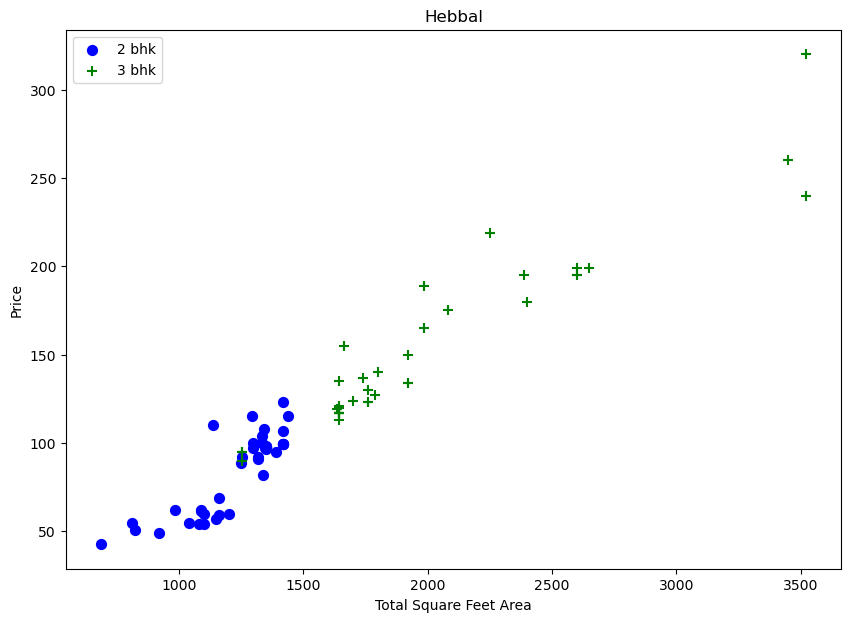

In [38]:
plot_scatter_chart(df7,'Hebbal')

Text(0, 0.5, 'Count')

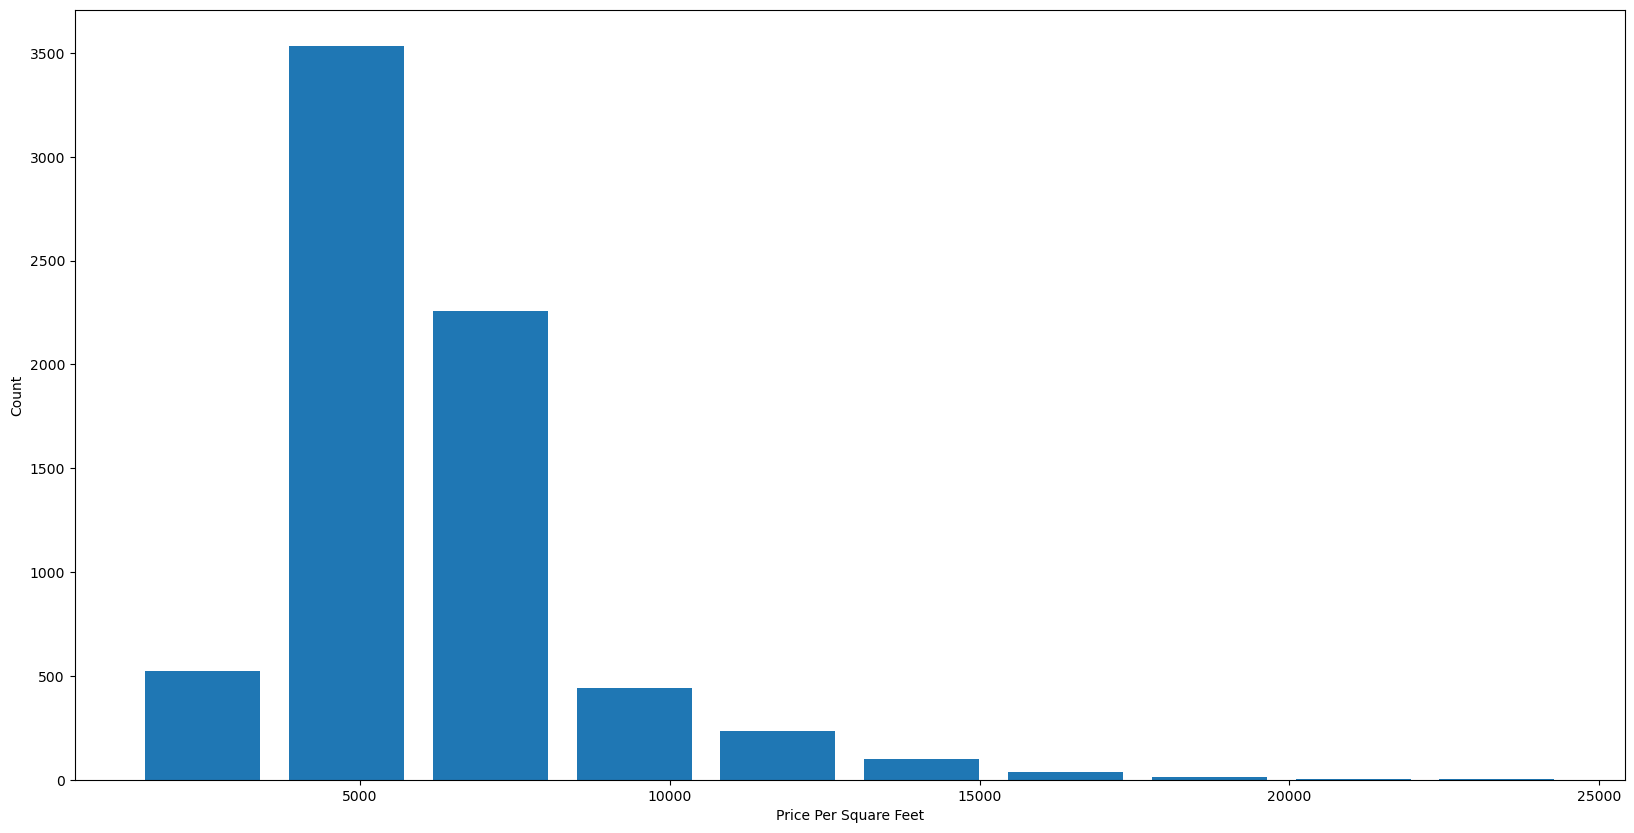

In [39]:
import matplotlib 
matplotlib.rcParams['figure.figsize']=(20,10)
plt.hist(df7['price_per_sqft'], rwidth=0.8)
plt.xlabel('Price Per Square Feet')
plt.ylabel('Count')


In [40]:
df7['price_per_sqft'].describe()

count     7150.000000
mean      6096.335091
std       2351.968298
min       1300.000000
25%       4603.174603
50%       5670.514805
75%       6855.975295
max      24509.803922
Name: price_per_sqft, dtype: float64

In [41]:
# we went to our business manager he told us anytime we have number of bathrooms greater than bhk + 2 it is an outlier
df8=df7[~(df7['bath']> (df7['bhk']+2))]
df8

,location,size,total_sqft,bath,price,bhk,price_per_sqft,total_sqft_per_bhk
0,1st Block Jayanagar,4 BHK,2850.0,4.0,428.0,4,15017.543860,712.500000
1,1st Block Jayanagar,3 BHK,1630.0,3.0,194.0,3,11901.840491,543.333333
2,1st Block Jayanagar,3 BHK,1875.0,2.0,235.0,3,12533.333333,625.000000
3,1st Block Jayanagar,3 BHK,1200.0,2.0,130.0,3,10833.333333,400.000000
4,1st Block Jayanagar,2 BHK,1235.0,2.0,148.0,2,11983.805668,617.500000
...,...,...,...,...,...,...,...,...
10009,other,2 BHK,1200.0,2.0,70.0,2,5833.333333,600.000000
10010,other,1 BHK,1800.0,1.0,200.0,1,11111.111111,1800.000000
10013,other,2 BHK,1353.0,2.0,110.0,2,8130.081301,676.500000
10014,other,1 Bedroom,812.0,1.0,26.0,1,3201.970443,812.000000


Text(0, 0.5, 'count')

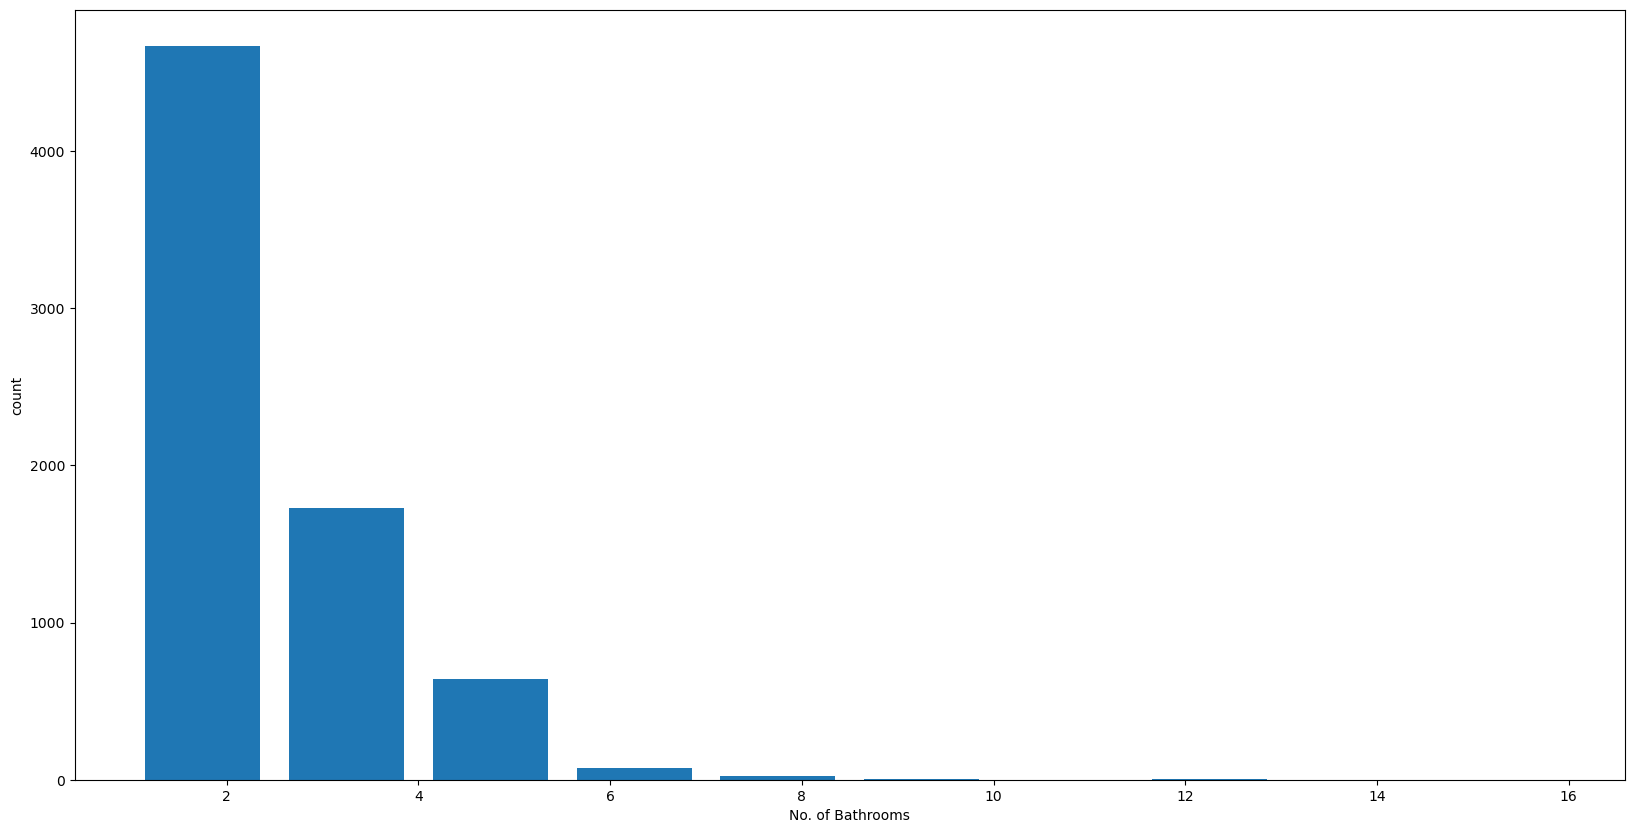

In [42]:
plt.hist(df7['bath'],rwidth=0.8)
plt.xlabel('No. of Bathrooms')
plt.ylabel('count')

In [43]:
df8= df8.drop(['price_per_sqft','size','total_sqft_per_bhk'],axis='columns')

In [44]:
df8

,location,total_sqft,bath,price,bhk
0,1st Block Jayanagar,2850.0,4.0,428.0,4
1,1st Block Jayanagar,1630.0,3.0,194.0,3
2,1st Block Jayanagar,1875.0,2.0,235.0,3
3,1st Block Jayanagar,1200.0,2.0,130.0,3
4,1st Block Jayanagar,1235.0,2.0,148.0,2
...,...,...,...,...,...
10009,other,1200.0,2.0,70.0,2
10010,other,1800.0,1.0,200.0,1
10013,other,1353.0,2.0,110.0,2
10014,other,812.0,1.0,26.0,1


In [45]:
## Our Machine learning starts to build from here (Training our model on this cleaned dataset) 

In [46]:
dummies = pd.get_dummies(df8['location']).astype(int)
dummies

,1st Block Jayanagar,1st Phase JP Nagar,2nd Phase Judicial Layout,2nd Stage Nagarbhavi,5th Block Hbr Layout,5th Phase JP Nagar,6th Phase JP Nagar,7th Phase JP Nagar,8th Phase JP Nagar,9th Phase JP Nagar,...,Vishveshwarya Layout,Vishwapriya Layout,Vittasandra,Whitefield,Yelachenahalli,Yelahanka,Yelahanka New Town,Yelenahalli,Yeshwanthpur,other
0,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10009,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
10010,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
10013,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
10014,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1


In [47]:
df9= pd.concat([df8,dummies.drop('other',axis='columns')], axis='columns')

In [ ]:
df9

In [ ]:
df10=df9.drop(['location'], axis='columns')

In [ ]:
r=df10.columns.delete(2)

In [73]:
df10

,total_sqft,bath,price,bhk,1st Block Jayanagar,1st Phase JP Nagar,2nd Phase Judicial Layout,2nd Stage Nagarbhavi,5th Block Hbr Layout,5th Phase JP Nagar,...,Vijayanagar,Vishveshwarya Layout,Vishwapriya Layout,Vittasandra,Whitefield,Yelachenahalli,Yelahanka,Yelahanka New Town,Yelenahalli,Yeshwanthpur
0,2850.0,4.0,428.0,4,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,1630.0,3.0,194.0,3,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1875.0,2.0,235.0,3,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,1200.0,2.0,130.0,3,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,1235.0,2.0,148.0,2,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10009,1200.0,2.0,70.0,2,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
10010,1800.0,1.0,200.0,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
10013,1353.0,2.0,110.0,2,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
10014,812.0,1.0,26.0,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [74]:
X= df10.drop('price', axis='columns')
y= df10['price']

In [75]:
from sklearn.model_selection import train_test_split
X_train,X_test , y_train, y_test= train_test_split(X,y, test_size=0.2,random_state=10)


In [76]:
df10

,total_sqft,bath,price,bhk,1st Block Jayanagar,1st Phase JP Nagar,2nd Phase Judicial Layout,2nd Stage Nagarbhavi,5th Block Hbr Layout,5th Phase JP Nagar,...,Vijayanagar,Vishveshwarya Layout,Vishwapriya Layout,Vittasandra,Whitefield,Yelachenahalli,Yelahanka,Yelahanka New Town,Yelenahalli,Yeshwanthpur
0,2850.0,4.0,428.0,4,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,1630.0,3.0,194.0,3,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1875.0,2.0,235.0,3,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,1200.0,2.0,130.0,3,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,1235.0,2.0,148.0,2,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10009,1200.0,2.0,70.0,2,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
10010,1800.0,1.0,200.0,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
10013,1353.0,2.0,110.0,2,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
10014,812.0,1.0,26.0,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [77]:
from sklearn.linear_model import LinearRegression
mlr = LinearRegression()
mlr.fit(X_train,y_train)
y_pred= mlr.predict(X_test)

In [78]:
dfr= pd.DataFrame(X_test , columns= r)

In [79]:
dfr

,total_sqft,bath,bhk,1st Block Jayanagar,1st Phase JP Nagar,2nd Phase Judicial Layout,2nd Stage Nagarbhavi,5th Block Hbr Layout,5th Phase JP Nagar,6th Phase JP Nagar,...,Vijayanagar,Vishveshwarya Layout,Vishwapriya Layout,Vittasandra,Whitefield,Yelachenahalli,Yelahanka,Yelahanka New Town,Yelenahalli,Yeshwanthpur
4263,726.0,2.0,2,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
6801,1150.0,2.0,2,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3792,991.0,2.0,2,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
7180,1745.0,3.0,3,0,0,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,0
9498,4000.0,6.0,6,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9907,2559.0,1.0,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1267,1035.0,2.0,2,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
6929,1520.0,2.0,3,0,0,0,0,0,0,0,...,1,0,0,0,0,0,0,0,0,0
3112,1079.0,2.0,2,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [80]:
dfr['price_test']= y_test
dfr['price_predicted']=y_pred

In [81]:
dfr

,total_sqft,bath,bhk,1st Block Jayanagar,1st Phase JP Nagar,2nd Phase Judicial Layout,2nd Stage Nagarbhavi,5th Block Hbr Layout,5th Phase JP Nagar,6th Phase JP Nagar,...,Vishwapriya Layout,Vittasandra,Whitefield,Yelachenahalli,Yelahanka,Yelahanka New Town,Yelenahalli,Yeshwanthpur,price_test,price_predicted
4263,726.0,2.0,2,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,35.0,23.824471
6801,1150.0,2.0,2,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,46.0,47.017906
3792,991.0,2.0,2,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,64.0,46.765295
7180,1745.0,3.0,3,0,0,0,0,0,0,0,...,0,0,1,0,0,0,0,0,100.0,114.209139
9498,4000.0,6.0,6,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,460.0,326.773622
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9907,2559.0,1.0,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,55.0,204.656022
1267,1035.0,2.0,2,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,41.0,37.844006
6929,1520.0,2.0,3,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,103.0,103.849392
3112,1079.0,2.0,2,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,41.0,45.972872


In [82]:
mlr.score(X_test,y_test)

0.8551162624515845

In [107]:
def predict_price(location,total_sqft,bath,bhk) :
    x=np.zeros(len(X.columns))
    loc_index= np.where(X.columns==location)[0]
    x[0]= total_sqft
    x[1]= bath
    x[2]= bhk
    
    if len(loc_index)>0 :
        x[loc_index[0]]=1
    x_df= pd.DataFrame([x], columns= X.columns)
    y= mlr.predict(x_df)
    return y 


In [108]:
predict_price('Whitefield',1745,3,3)

array([114.20913942])

In [109]:
predict_price('other',1000,2,2)

array([79.41176445])

In [110]:
dummies.columns

Index(['1st Block Jayanagar', '1st Phase JP Nagar',
       '2nd Phase Judicial Layout', '2nd Stage Nagarbhavi',
       '5th Block Hbr Layout', '5th Phase JP Nagar', '6th Phase JP Nagar',
       '7th Phase JP Nagar', '8th Phase JP Nagar', '9th Phase JP Nagar',
       ...
       'Vishveshwarya Layout', 'Vishwapriya Layout', 'Vittasandra',
       'Whitefield', 'Yelachenahalli', 'Yelahanka', 'Yelahanka New Town',
       'Yelenahalli', 'Yeshwanthpur', 'other'],
      dtype='object', length=241)